# 🛡️ Fraud Detection in Finance — Version 2.0

**Author:** Your Name  
**Dataset:** Fraudulent E-Commerce Transactions (Kaggle) — **échantillon réduit 15 000 lignes**  
**Models:** Autoencoder · LSTM · XGBoost · Ensemble (LSTM + XGBoost)  

> ⚡ Cette version utilise un sous-ensemble de 15 000 transactions pour accélérer l'entraînement.
> L'ensemble final combine **LSTM** (comportement séquentiel) + **XGBoost** (gradient boosting).

---
### 📋 Pipeline
1. Data Loading & Sampling (15 000 lignes)
2. EDA rapide
3. Advanced Feature Engineering
4. Autoencoder (Anomaly Detection — référence)
5. LSTM (Behavioral Sequence — inclus dans l'ensemble)
6. XGBoost (Gradient Boosting — inclus dans l'ensemble)
7. Ensemble LSTM + XGBoost
8. Export des modèles pour l'API


In [2]:
# ── 0. Installation ──────────────────────────────────────────────
!pip install -q kagglehub tensorflow scikit-learn matplotlib seaborn xgboost imbalanced-learn shap joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import xgboost as xgb
import shap

from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve,
                              precision_recall_curve, average_precision_score,
                              f1_score)
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import SMOTE

np.random.seed(42)
tf.random.set_seed(42)
print(f"TensorFlow: {tf.__version__} | XGBoost: {xgb.__version__}")

TensorFlow: 2.20.0 | XGBoost: 3.2.0


## 📥 Étape 1 — Chargement des données

In [3]:
import kagglehub

path = kagglehub.dataset_download("shriyashjagtap/fraudulent-e-commerce-transactions")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df_full = pd.read_csv(os.path.join(path, csv_file))

print(f"✅ Dataset complet: {df_full.shape[0]:,} lignes × {df_full.shape[1]} colonnes")

# ── Sous-échantillonnage stratifié (15 000 lignes) ────────────────
SAMPLE_SIZE = 15_000
target_raw = [c for c in df_full.columns if 'fraud' in c.lower()][0]
df_raw = (
    df_full
    .groupby(target_raw, group_keys=False)
    .apply(lambda g: g.sample(min(len(g), int(SAMPLE_SIZE * len(g) / len(df_full))), random_state=42))
    .sample(frac=1, random_state=42)  # shuffle
    .reset_index(drop=True)
)

print(f"🎯 Sous-échantillon: {df_raw.shape[0]:,} lignes (stratifié par classe)")
print(f"\n📋 Colonnes: {df_raw.columns.tolist()}")
df_raw.head()


Using Colab cache for faster access to the 'fraudulent-e-commerce-transactions' dataset.
✅ Dataset complet: 1,472,952 lignes × 16 colonnes
🎯 Sous-échantillon: 14,999 lignes (stratifié par classe)

📋 Colonnes: ['Transaction ID', 'Customer ID', 'Transaction Amount', 'Transaction Date', 'Payment Method', 'Product Category', 'Quantity', 'Customer Age', 'Customer Location', 'Device Used', 'IP Address', 'Shipping Address', 'Billing Address', 'Is Fraudulent', 'Account Age Days', 'Transaction Hour']


,Transaction ID,Customer ID,Transaction Amount,Transaction Date,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,Shipping Address,Billing Address,Is Fraudulent,Account Age Days,Transaction Hour
0,7682fb2d-d7d7-4a44-8c8a-dbc77a5abe8a,b9340586-ebae-4d7f-8fa0-2163f2e886b3,762.85,2024-02-28 10:23:39,debit card,health & beauty,3,47,Humphreystad,tablet,223.198.242.157,"37584 Powell Freeway\nDixonton, KY 25234","37584 Powell Freeway\nDixonton, KY 25234",0,276,10
1,c6230c7f-d9ff-4742-8a55-c6b0e7f70ce5,1e764ee8-fc0e-41b2-b91d-da10480f111b,87.47,2024-01-10 11:13:08,PayPal,clothing,5,24,North Johnny,mobile,9.85.150.3,USS Walsh\nFPO AA 49823,"9716 Martin Dam\nSarahfurt, NY 56141",0,94,11
2,566d4ae8-9f92-4406-9fe8-ed5e88f6fc17,79498eba-685a-468f-87ee-1e504826df04,244.56,2024-01-20 16:07:44,credit card,home & garden,1,39,Port Karen,mobile,177.23.76.77,"27825 Danielle Ranch\nMayomouth, HI 59861","27825 Danielle Ranch\nMayomouth, HI 59861",0,46,16
3,33f2a95f-57f1-495e-b3ba-5985f9c0abc5,a326f9c5-08f9-449a-b845-492cd2989f79,28.55,2024-01-11 12:27:21,PayPal,health & beauty,1,32,South Holly,tablet,98.21.35.244,"2904 Franklin Ridges Suite 793\nTylerberg, AL ...","5086 Gordon Crest\nLake Jessica, MD 71929",0,227,12
4,496b2b6b-032d-40d4-b86a-967ea78b0eac,7de33d02-cbdf-4454-a1a1-dacac30186d8,299.70,2024-01-12 03:38:39,bank transfer,electronics,2,28,New Steven,tablet,23.228.44.16,"443 Mendez Drive Suite 230\nNorth Garyside, MN...","443 Mendez Drive Suite 230\nNorth Garyside, MN...",0,1,3


## 🔍 Étape 2 — EDA Avancé

🎯 Colonne cible: 'Is_Fraudulent'
📊 Fraudes: 751 (5.01%)

❓ Valeurs manquantes:
  Aucune valeur manquante


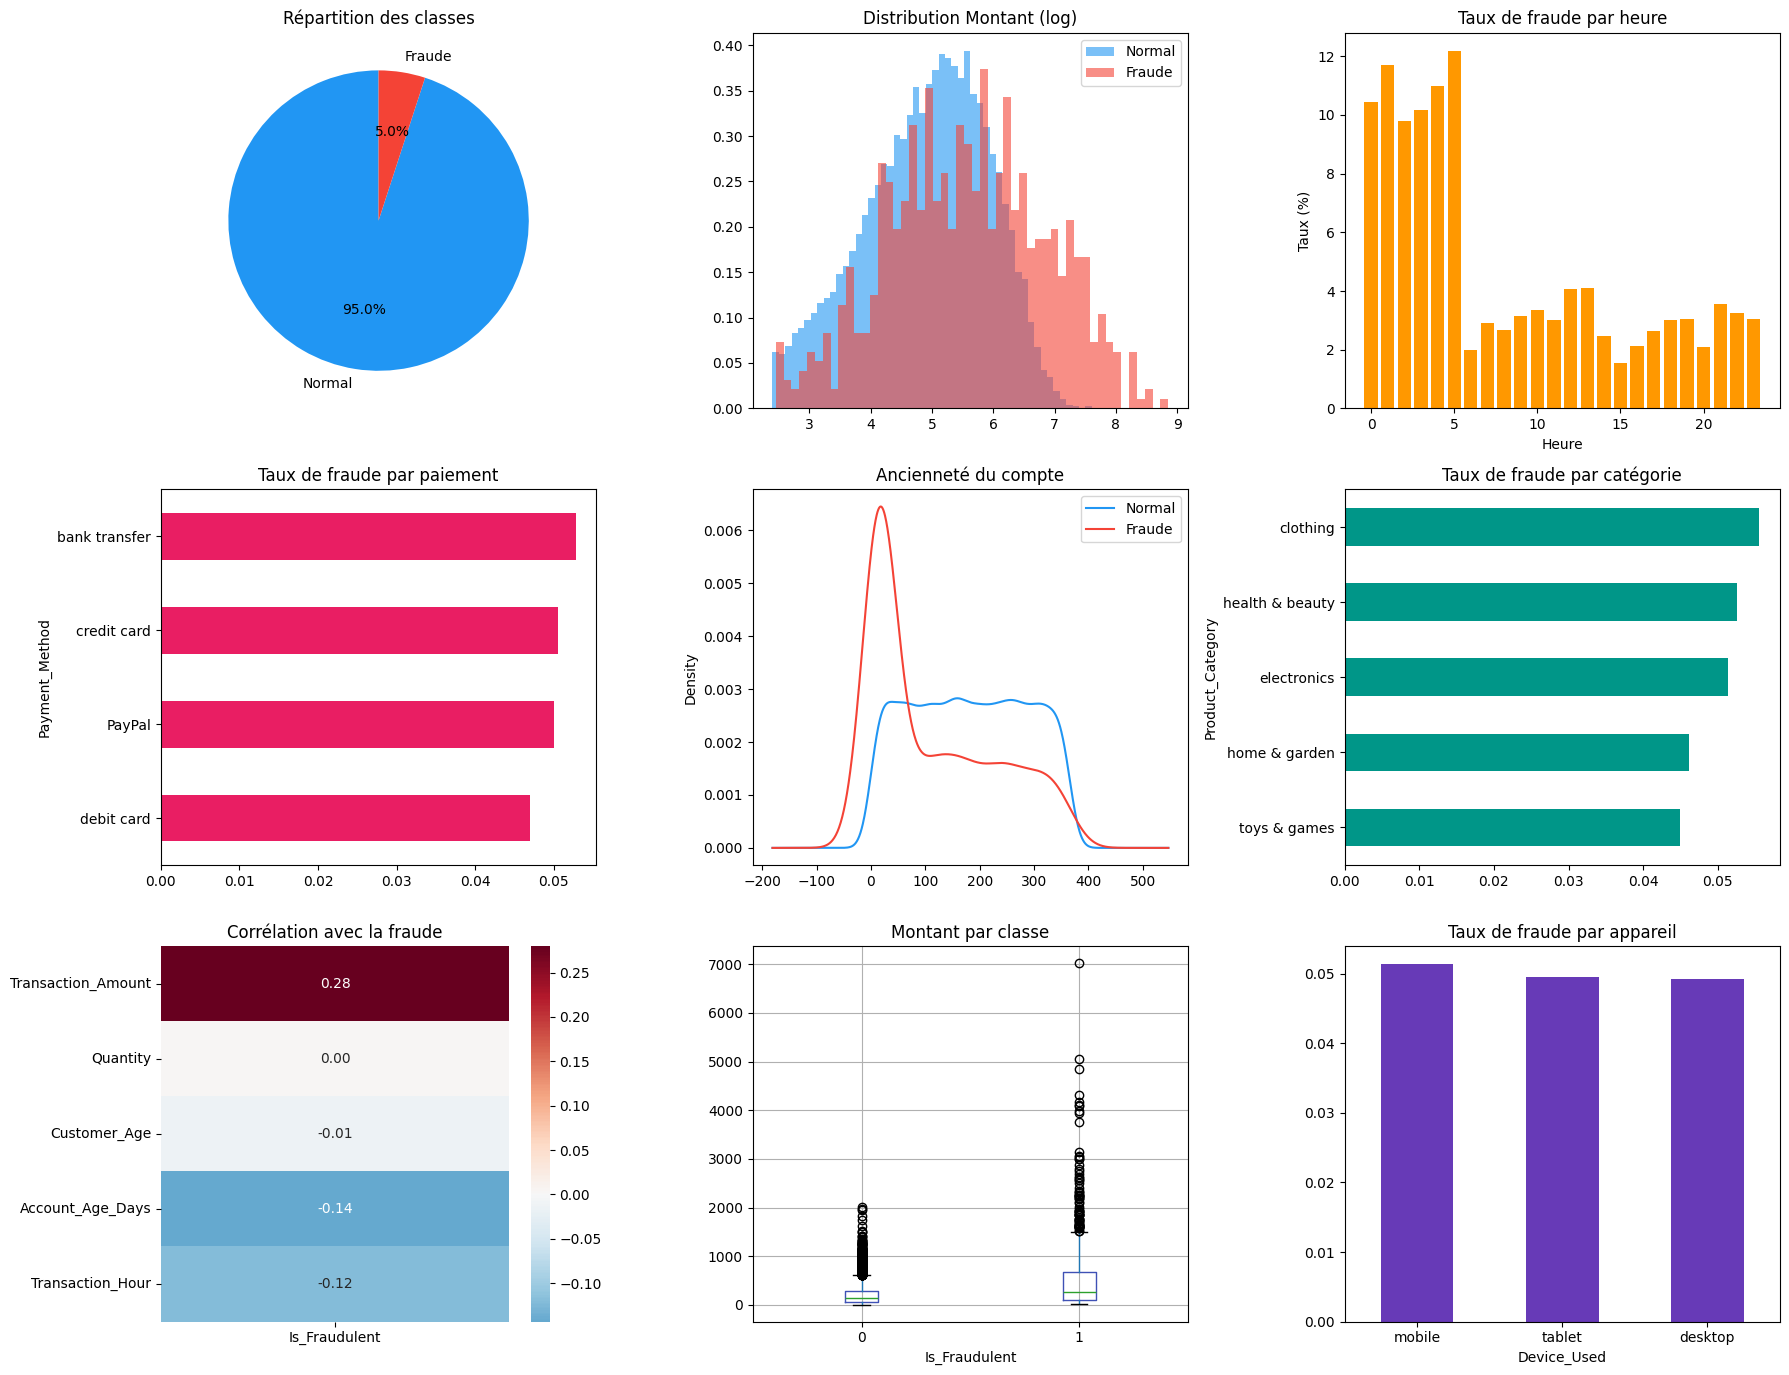

✅ EDA saved to docs/eda_plots.png


In [4]:
import os

df = df_raw.copy()
df.columns = [c.strip().replace(' ', '_') for c in df.columns]
target_col = [c for c in df.columns if 'fraud' in c.lower()][0]

print(f"🎯 Colonne cible: '{target_col}'")
print(f"📊 Fraudes: {df[target_col].sum():,} ({df[target_col].mean()*100:.2f}%)")
print(f"\n❓ Valeurs manquantes:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else '  Aucune valeur manquante')

# ── EDA : 9 graphiques ───────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle("EDA — Fraudulent E-Commerce Transactions v2", fontsize=16, fontweight='bold', y=1.01)

# 1. Distribution des classes
counts = df[target_col].value_counts()
axes[0,0].pie(counts, labels=['Normal','Fraude'], autopct='%1.1f%%',
              colors=['#2196F3','#F44336'], startangle=90)
axes[0,0].set_title("Répartition des classes")

# 2. Distribution du montant (log scale)
for label, color in [(0,'#2196F3'), (1,'#F44336')]:
    subset = df[df[target_col]==label]['Transaction_Amount']
    axes[0,1].hist(np.log1p(subset), bins=50, alpha=0.6,
                   label=f"{'Normal' if label==0 else 'Fraude'}", color=color, density=True)
axes[0,1].set_title("Distribution Montant (log)")
axes[0,1].legend()

# 3. Taux de fraude par heure
if 'Transaction_Hour' in df.columns:
    fraud_by_hour = df.groupby('Transaction_Hour')[target_col].mean() * 100
    axes[0,2].bar(fraud_by_hour.index, fraud_by_hour.values, color='#FF9800')
    axes[0,2].set_title("Taux de fraude par heure")
    axes[0,2].set_xlabel("Heure")
    axes[0,2].set_ylabel("Taux (%)")

# 4. Méthode de paiement
if 'Payment_Method' in df.columns:
    fraud_by_pay = df.groupby('Payment_Method')[target_col].agg(['mean','count'])
    fraud_by_pay['mean'].sort_values().plot(kind='barh', ax=axes[1,0], color='#E91E63')
    axes[1,0].set_title("Taux de fraude par paiement")

# 5. Ancienneté du compte
if 'Account_Age_Days' in df.columns:
    for label, color in [(0,'#2196F3'), (1,'#F44336')]:
        df[df[target_col]==label]['Account_Age_Days'].plot(
            kind='kde', ax=axes[1,1], label=f"{'Normal' if label==0 else 'Fraude'}", color=color)
    axes[1,1].set_title("Ancienneté du compte")
    axes[1,1].legend()

# 6. Catégorie produit
if 'Product_Category' in df.columns:
    fraud_by_cat = df.groupby('Product_Category')[target_col].mean().sort_values()
    fraud_by_cat.plot(kind='barh', ax=axes[1,2], color='#009688')
    axes[1,2].set_title("Taux de fraude par catégorie")

# 7. Corrélation heatmap
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()[[target_col]].drop(target_col)
sns.heatmap(corr, ax=axes[2,0], annot=True, fmt='.2f', cmap='RdBu_r', center=0)
axes[2,0].set_title("Corrélation avec la fraude")

# 8. Boxplot montant
df.boxplot(column='Transaction_Amount', by=target_col, ax=axes[2,1],
           boxprops=dict(color='#3F51B5'))
plt.sca(axes[2,1])
plt.title("Montant par classe")
plt.suptitle('')

# 9. Device used
if 'Device_Used' in df.columns:
    fraud_by_dev = df.groupby('Device_Used')[target_col].mean().sort_values(ascending=False)
    fraud_by_dev.plot(kind='bar', ax=axes[2,2], color='#673AB7', rot=0)
    axes[2,2].set_title("Taux de fraude par appareil")

plt.tight_layout()

# On crée le dossier '../docs' s'il n'existe pas
os.makedirs('../docs', exist_ok=True)

plt.savefig('../docs/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA saved to docs/eda_plots.png")

## ⚙️ Étape 3 — Feature Engineering Avancé

In [5]:
def feature_engineering(df, target_col):
    """Pipeline de feature engineering avancé."""
    df = df.copy()

    # ── Features temporelles ─────────────────────────────────────
    if 'Transaction_Date' in df.columns:
        df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], errors='coerce')
        df['tx_day_of_week']   = df['Transaction_Date'].dt.dayofweek
        df['tx_day_of_month']  = df['Transaction_Date'].dt.day
        df['tx_month']         = df['Transaction_Date'].dt.month
        df['tx_is_weekend']    = (df['tx_day_of_week'] >= 5).astype(int)
        df['tx_is_night']      = df['Transaction_Hour'].apply(
            lambda h: 1 if (h >= 22 or h <= 5) else 0) if 'Transaction_Hour' in df.columns else 0

    # ── Features de montant ──────────────────────────────────────
    if 'Transaction_Amount' in df.columns:
        df['amount_log']       = np.log1p(df['Transaction_Amount'])
        df['amount_per_unit']  = df['Transaction_Amount'] / (df['Quantity'] + 1) \
                                 if 'Quantity' in df.columns else df['Transaction_Amount']
        # Montant vs médiane par catégorie
        if 'Product_Category' in df.columns:
            cat_median = df.groupby('Product_Category')['Transaction_Amount'].transform('median')
            df['amount_vs_cat_median'] = df['Transaction_Amount'] / (cat_median + 1)

    # ── Features d'identité ──────────────────────────────────────
    if 'Shipping_Address' in df.columns and 'Billing_Address' in df.columns:
        df['same_address'] = (df['Shipping_Address'] == df['Billing_Address']).astype(int)

    # ── Features de vélocité client ──────────────────────────────
    if 'Customer_ID' in df.columns and 'Transaction_Amount' in df.columns:
        grp = df.groupby('Customer_ID')['Transaction_Amount']
        df['customer_tx_count'] = df.groupby('Customer_ID')['Transaction_Amount'].transform('count')
        df['customer_avg_amount'] = grp.transform('mean')
        df['customer_std_amount'] = grp.transform('std').fillna(0)
        df['amount_zscore'] = (df['Transaction_Amount'] - df['customer_avg_amount']) / \
                              (df['customer_std_amount'] + 1e-8)

    # ── Encoder catégorielles ────────────────────────────────────
    cat_cols = ['Payment_Method', 'Product_Category', 'Device_Used']
    le = LabelEncoder()
    for col in cat_cols:
        if col in df.columns:
            df[col + '_enc'] = le.fit_transform(df[col].astype(str))

    return df

df = feature_engineering(df, target_col)

# Sélection des features finales
base_features = ['Transaction_Amount', 'Quantity', 'Customer_Age',
                 'Account_Age_Days', 'Transaction_Hour']
new_features  = ['amount_log', 'amount_per_unit', 'amount_vs_cat_median',
                 'tx_is_weekend', 'tx_is_night', 'tx_day_of_week',
                 'tx_month', 'same_address',
                 'customer_tx_count', 'customer_avg_amount',
                 'customer_std_amount', 'amount_zscore']
enc_features  = ['Payment_Method_enc', 'Product_Category_enc', 'Device_Used_enc']

all_features = [f for f in base_features + new_features + enc_features if f in df.columns]

print(f"✅ Features engineering: {len(base_features)} → {len(all_features)} features")
print(f"   Nouvelles features: {[f for f in new_features if f in df.columns]}")

X = df[all_features].fillna(0).values
y = df[target_col].values

# RobustScaler (plus résistant aux outliers)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# SMOTE pour gérer le déséquilibre (XGBoost)
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

X_train_normal = X_train[y_train == 0]
print(f"\n📐 Données: Train={X_train.shape} | Test={X_test.shape}")
print(f"   SMOTE: {X_train_sm.shape} (équilibré)")

# Sauvegarder les feature names pour l'API
import json
os.makedirs('../models', exist_ok=True)
with open('../models/feature_names.json', 'w') as f:
    json.dump(all_features, f)
print("✅ Feature names sauvegardés")

✅ Features engineering: 5 → 20 features
   Nouvelles features: ['amount_log', 'amount_per_unit', 'amount_vs_cat_median', 'tx_is_weekend', 'tx_is_night', 'tx_day_of_week', 'tx_month', 'same_address', 'customer_tx_count', 'customer_avg_amount', 'customer_std_amount', 'amount_zscore']

📐 Données: Train=(11999, 20) | Test=(3000, 20)
   SMOTE: (22796, 20) (équilibré)
✅ Feature names sauvegardés


## 🤖 Étape 4 — Autoencoder

In [6]:
print("\n" + "="*60)
print("  AUTOENCODER — Détection d'anomalies (non supervisé)")
print("="*60)

input_dim  = X_scaled.shape[1]
latent_dim = 4  # Augmenté

# Architecture améliorée
inputs  = keras.Input(shape=(input_dim,), name='input')
x       = layers.Dense(64, activation='relu')(inputs)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.3)(x)
x       = layers.Dense(32, activation='relu')(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.2)(x)
encoded = layers.Dense(latent_dim, activation='relu', name='latent')(x)

x       = layers.Dense(32, activation='relu')(encoded)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.2)(x)
x       = layers.Dense(64, activation='relu')(x)
x       = layers.BatchNormalization()(x)
decoded = layers.Dense(input_dim, activation='linear', name='output')(x)

autoencoder = Model(inputs, decoded, name='Autoencoder_v2')
encoder     = Model(inputs, encoded, name='Encoder')

autoencoder.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')

history_ae = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=30, batch_size=256,  # réduit pour entraînement rapide
    validation_split=0.1,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.5, patience=3),
        ModelCheckpoint('../models/autoencoder.h5', save_best_only=True, verbose=0)
    ],
    verbose=1
)

recon_test  = autoencoder.predict(X_test, verbose=0)
recon_error = np.mean(np.square(X_test - recon_test), axis=1)
recon_train = autoencoder.predict(X_train_normal, verbose=0)
recon_train_error = np.mean(np.square(X_train_normal - recon_train), axis=1)
threshold   = np.percentile(recon_train_error, 95)

y_pred_ae = (recon_error > threshold).astype(int)
auc_ae    = roc_auc_score(y_test, recon_error)
ap_ae     = average_precision_score(y_test, recon_error)

print(f"\n📊 Seuil: {threshold:.5f}")
print(f"   AUC-ROC: {auc_ae:.4f}  |  Avg Precision: {ap_ae:.4f}")
print(classification_report(y_test, y_pred_ae, target_names=['Normal','Fraude']))

# Sauvegarder le threshold
np.save('../models/ae_threshold.npy', threshold)
print("✅ Autoencoder sauvegardé")


  AUTOENCODER — Détection d'anomalies (non supervisé)
Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 1.5488

41/41 ━━━━━━━━━━━━━━━━━━━━ 21s 144ms/step - loss: 1.1459 - val_loss: 0.3257 - learning_rate: 0.0010
Epoch 2/30
38/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5513

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4953 - val_loss: 0.2926 - learning_rate: 0.0010
Epoch 3/30
38/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3743

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3571 - val_loss: 0.2615 - learning_rate: 0.0010
Epoch 4/30
34/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3127

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3058 - val_loss: 0.2370 - learning_rate: 0.0010
Epoch 5/30
38/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2765

...

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1713 - val_loss: 0.1387 - learning_rate: 0.0010
Epoch 27/30
37/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1683

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1700 - val_loss: 0.1363 - learning_rate: 0.0010
Epoch 28/30
35/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1673

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1683 - val_loss: 0.1352 - learning_rate: 0.0010
Epoch 29/30
33/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1644

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1667 - val_loss: 0.1342 - learning_rate: 0.0010
Epoch 30/30
39/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1642

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1652 - val_loss: 0.1331 - learning_rate: 0.0010

📊 Seuil: 0.23632
   AUC-ROC: 0.6693  |  Avg Precision: 0.2548
              precision    recall  f1-score   support

      Normal       0.96      0.95      0.95      2850
      Fraude       0.21      0.26      0.23       150

    accuracy                           0.91      3000
   macro avg       0.58      0.60      0.59      3000
weighted avg       0.92      0.91      0.92      3000

✅ Autoencoder sauvegardé


## 🔁 Étape 5 — LSTM

In [7]:
print("\n" + "="*60)
print("  LSTM — Comportement temporel par client")
print("="*60)

SEQ_LEN = 10
df_lstm = df.copy()
df_lstm['feature_vec'] = list(X_scaled)

def build_sequences(df_src, target, seq_len=10):
    seqs, labels = [], []
    grp_col = 'Customer_ID' if 'Customer_ID' in df_src.columns else None
    groups = df_src.groupby(grp_col) if grp_col else [(0, df_src.iloc[i*seq_len:(i+1)*seq_len]) for i in range(len(df_src)//seq_len)]
    for _, group in df_src.groupby(grp_col) if grp_col else [(0, df_src)]:
        if 'Transaction_Date' in group.columns:
            group = group.sort_values('Transaction_Date')
        feats = np.stack(group['feature_vec'].values)
        label = int(group[target].max())
        if len(feats) >= seq_len:
            seqs.append(feats[-seq_len:])
        else:
            pad = np.zeros((seq_len - len(feats), feats.shape[1]))
            seqs.append(np.vstack([pad, feats]))
        labels.append(label)
    return np.array(seqs), np.array(labels)

X_seq, y_seq = build_sequences(df_lstm, target_col, SEQ_LEN)
print(f"Séquences: {X_seq.shape} | Fraudes: {y_seq.sum()} ({y_seq.mean()*100:.1f}%)")

X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq)

# Architecture LSTM améliorée avec Attention
seq_input = keras.Input(shape=(SEQ_LEN, X_seq.shape[2]), name='seq_input')
x = layers.LSTM(64, return_sequences=True)(seq_input)
x = layers.Dropout(0.3)(x)
x = layers.LSTM(32, return_sequences=True)(x)
x = layers.Dropout(0.3)(x)
# Self-attention simple
attn = layers.Dense(1, activation='tanh')(x)
attn = layers.Flatten()(attn)
attn = layers.Activation('softmax')(attn)
attn = layers.RepeatVector(32)(attn)  # doit correspondre à la 2ème LSTM
attn = layers.Permute([2, 1])(attn)
x = layers.Multiply()([x, attn])
x = layers.Lambda(lambda t: tf.reduce_sum(t, axis=1))(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(1, activation='sigmoid')(x)

lstm_model = Model(seq_input, out, name='LSTM_Attention')
lstm_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

neg, pos = np.bincount(y_tr_s)
class_weight = {0: 1.0, 1: neg / pos}

history_lstm = lstm_model.fit(
    X_tr_s, y_tr_s,
    epochs=20, batch_size=64,  # réduit pour entraînement rapide
    validation_split=0.15,
    class_weight=class_weight,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True, monitor='val_auc', mode='max'),
        ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_auc', mode='max'),
        ModelCheckpoint('../models/lstm_model.h5', save_best_only=True, verbose=0)
    ],
    verbose=1
)

y_proba_lstm = lstm_model.predict(X_te_s, verbose=0).flatten()
auc_lstm = roc_auc_score(y_te_s, y_proba_lstm)
ap_lstm  = average_precision_score(y_te_s, y_proba_lstm)
print(f"\n📊 LSTM AUC-ROC: {auc_lstm:.4f} | Avg Precision: {ap_lstm:.4f}")
print("✅ LSTM sauvegardé")


  LSTM — Comportement temporel par client
Séquences: (14999, 10, 20) | Fraudes: 751 (5.0%)
Epoch 1/20
156/160 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5717 - auc: 0.6510 - loss: 1.2646 - precision: 0.0757 - recall: 0.6266

160/160 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.6444 - auc: 0.7105 - loss: 1.1766 - precision: 0.0881 - recall: 0.6504 - val_accuracy: 0.9533 - val_auc: 0.7310 - val_loss: 0.6144 - val_precision: 0.6190 - val_recall: 0.1461 - learning_rate: 0.0010
Epoch 2/20
157/160 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7457 - auc: 0.7879 - loss: 1.0767 - precision: 0.1341 - recall: 0.7000

160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7522 - auc: 0.7881 - loss: 1.0488 - precision: 0.1295 - recall: 0.6875 - val_accuracy: 0.9472 - val_auc: 0.7455 - val_loss: 0.5344 - val_precision: 0.4286 - val_recall: 0.2022 - learning_rate: 0.0010
Epoch 3/20
158/160 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7816 - auc: 0.7876 - loss: 1.0602 - precision: 0.1471 - recall: 0.6532

160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7851 - auc: 0.7837 - loss: 1.0446 - precision: 0.1401 - recall: 0.6387 - val_accuracy: 0.9494 - val_auc: 0.7462 - val_loss: 0.3973 - val_precision: 0.4722 - val_recall: 0.1910 - learning_rate: 0.0010
Epoch 4/20
155/160 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7963 - auc: 0.7959 - loss: 1.0478 - precision: 0.1543 - recall: 0.6353

160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7882 - auc: 0.7926 - loss: 1.0358 - precision: 0.1424 - recall: 0.6406 - val_accuracy: 0.8983 - val_auc: 0.7470 - val_loss: 0.3953 - val_precision: 0.2099 - val_recall: 0.3820 - learning_rate: 0.0010
Epoch 5/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7833 - auc: 0.7894 - loss: 1.0358 - precision: 0.1418 - recall: 0.6562 - val_accuracy: 0.8644 - val_auc: 0.7476 - val_loss: 0.4270 - val_precision: 0.1784 - val_recall: 0.4831 - learning_rate: 0.0010
Epoch 6/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7960 - auc: 0.7993 - loss: 1.0204 - precision: 0.1493 - recall: 0.6523 - val_accuracy: 0.8389 - val_auc: 0.7479 - val_loss: 0.4698 - val_precision: 0.1616 - val_recall: 0.5393 - learning_rate: 0.0010
Epoch 7/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7912 - auc: 0.7891 - loss: 1.0409 - precision: 0.1452 - recall: 0.6465 - val_accuracy: 0.7778 - val_auc: 0.7487 - val_loss: 0.5346 - val_precis

160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7908 - auc: 0.8054 - loss: 1.0104 - precision: 0.1507 - recall: 0.6836 - val_accuracy: 0.8917 - val_auc: 0.7524 - val_loss: 0.3339 - val_precision: 0.1954 - val_recall: 0.3820 - learning_rate: 0.0010
Epoch 12/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7939 - auc: 0.8029 - loss: 1.0110 - precision: 0.1492 - recall: 0.6602 - val_accuracy: 0.7778 - val_auc: 0.7515 - val_loss: 0.5331 - val_precision: 0.1235 - val_recall: 0.5730 - learning_rate: 0.0010
Epoch 13/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7975 - auc: 0.8038 - loss: 1.0122 - precision: 0.1516 - recall: 0.6602 - val_accuracy: 0.6922 - val_auc: 0.7539 - val_loss: 0.6389 - val_precision: 0.1012 - val_recall: 0.6629 - learning_rate: 0.0010
Epoch 14/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7932 - auc: 0.8086 - loss: 1.0016 - precision: 0.1499 - recall: 0.6680 - val_accuracy: 0.8717 - val_auc: 0.7572 - val_loss: 0.3752 - val_pre

## ⚡ Étape 6 — XGBoost (Nouveau)


  XGBOOST — Gradient Boosting (supervisé)
[0]	validation_0-aucpr:0.12528
[50]	validation_0-aucpr:0.25067
[100]	validation_0-aucpr:0.31279
[150]	validation_0-aucpr:0.32516
[189]	validation_0-aucpr:0.32933

📊 XGBoost AUC-ROC: 0.7646 | Avg Precision: 0.3317
              precision    recall  f1-score   support

      Normal       0.97      0.85      0.91      2850
      Fraude       0.16      0.55      0.25       150

    accuracy                           0.83      3000
   macro avg       0.57      0.70      0.58      3000
weighted avg       0.93      0.83      0.87      3000



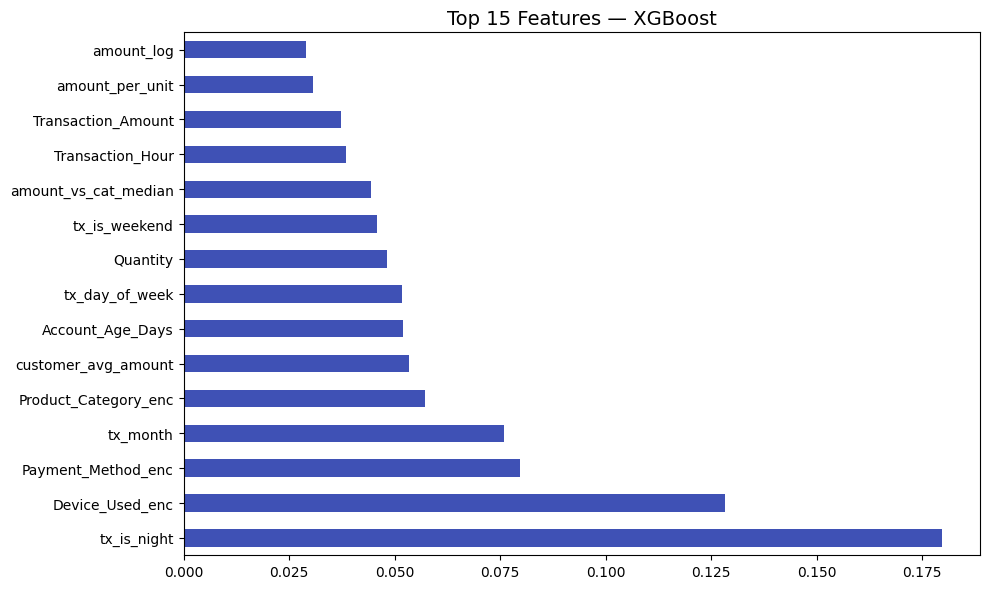

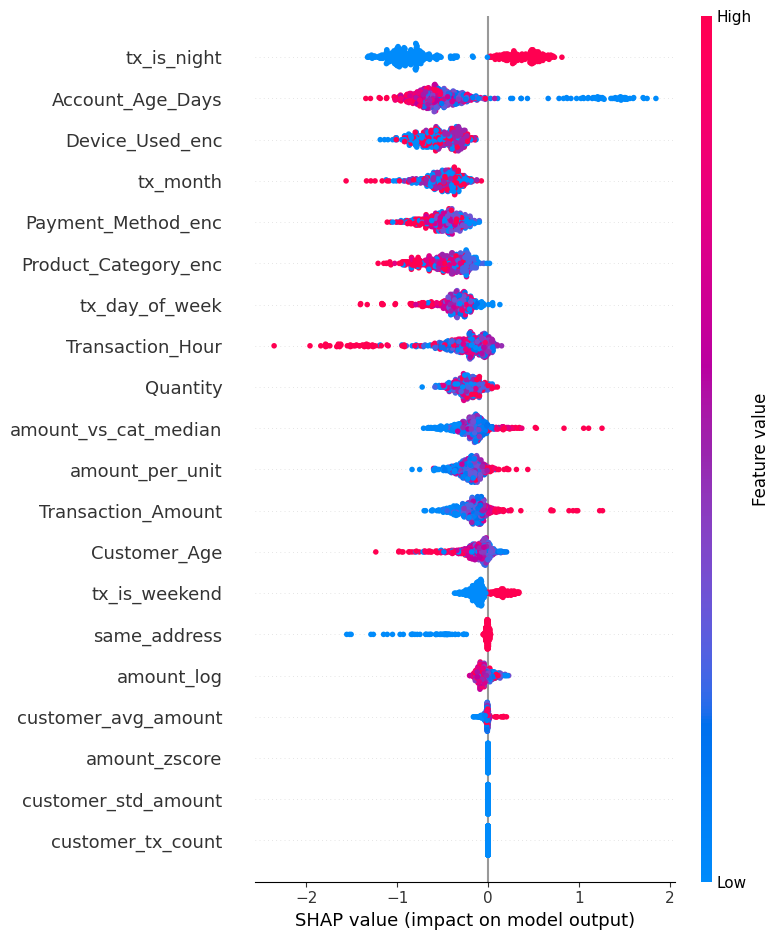

✅ XGBoost + Scaler sauvegardés


In [8]:
print("\n" + "="*60)
print("  XGBOOST — Gradient Boosting (supervisé)")
print("="*60)

neg, pos = np.bincount(y_train)
scale_pos = neg / pos

xgb_model = xgb.XGBClassifier(
    n_estimators=200,  # réduit pour entraînement rapide
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,  # gère le déséquilibre
    eval_metric='aucpr',
    early_stopping_rounds=15,
    random_state=42,
    tree_method='hist',
    verbosity=0
)

xgb_model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb  = (y_proba_xgb > 0.5).astype(int)
auc_xgb     = roc_auc_score(y_test, y_proba_xgb)
ap_xgb      = average_precision_score(y_test, y_proba_xgb)

print(f"\n📊 XGBoost AUC-ROC: {auc_xgb:.4f} | Avg Precision: {ap_xgb:.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=['Normal','Fraude']))

# Feature Importance
feat_imp = pd.Series(xgb_model.feature_importances_, index=all_features).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
feat_imp.head(15).plot(kind='barh', color='#3F51B5')
plt.title("Top 15 Features — XGBoost", fontsize=14)
plt.tight_layout()
plt.savefig('../docs/feature_importance.png', dpi=150)
plt.show()

# SHAP Values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test[:500])
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test[:500], feature_names=all_features, show=False)
plt.tight_layout()
plt.savefig('../docs/shap_summary.png', dpi=150)
plt.show()

# Sauvegarder XGBoost + scaler
joblib.dump(xgb_model, '../models/xgboost_model.pkl')
joblib.dump(scaler,    '../models/scaler.pkl')
print("✅ XGBoost + Scaler sauvegardés")

## 🎯 Étape 7 — Modèle Ensemble : LSTM + XGBoost

L'ensemble combine :
- **LSTM** (35%) : capture les patterns comportementaux séquentiels
- **XGBoost** (65%) : précision sur les features de transaction

> L'Autoencoder reste entraîné comme **référence de détection d'anomalies** mais n'est pas inclus dans l'ensemble final.



  ENSEMBLE FINAL — LSTM + XGBoost

📊 Résultats:
   Autoencoder  — AUC: 0.6693 | AP: 0.2548  (référence, non dans l'ensemble)
   XGBoost      — AUC: 0.7646 | AP: 0.3317
   LSTM         — AUC: 0.8030
   Ensemble     — AUC: 0.7878 | AP: 0.3663 | F1: 0.2843
              precision    recall  f1-score   support

      Normal       0.98      0.87      0.92      2850
      Fraude       0.19      0.58      0.28       150

    accuracy                           0.85      3000
   macro avg       0.58      0.72      0.60      3000
weighted avg       0.94      0.85      0.89      3000


             Modèle       Approche  AUC-ROC Avg Precision
        Autoencoder Non supervisée   0.6693        0.2548
            XGBoost     Supervisée   0.7646        0.3317
               LSTM   Séquentielle   0.8030             -
Ensemble (LSTM+XGB)        Hybride   0.7878        0.3663


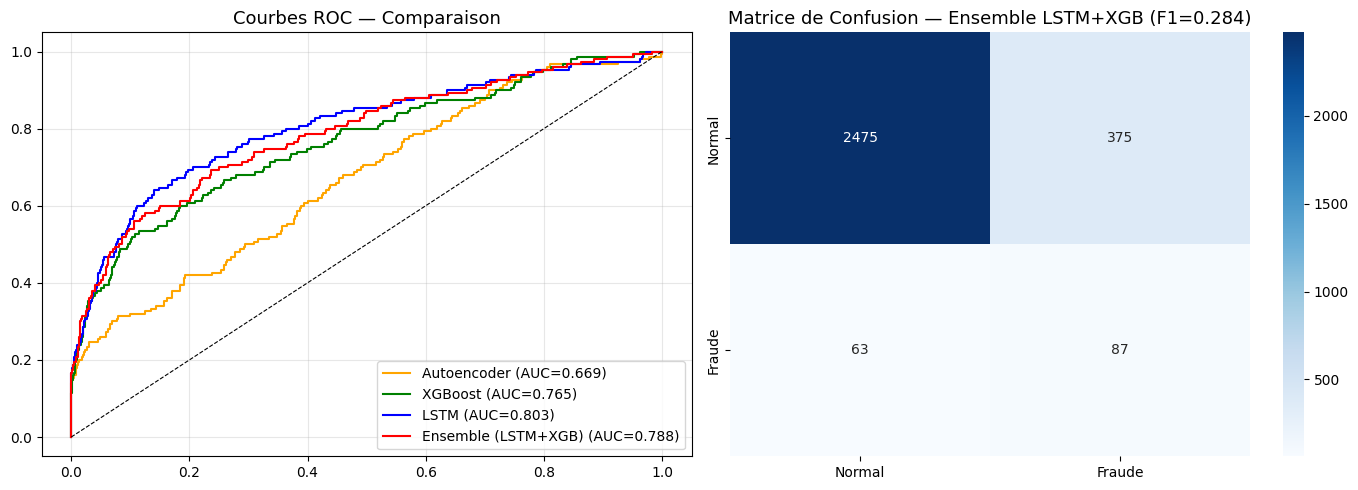


✅ Tous les modèles sauvegardés dans ../models/
   → xgboost_model.pkl, lstm_model.h5, autoencoder.h5
   → scaler.pkl, ae_threshold.npy, feature_names.json, ensemble_config.json


In [9]:
print("\n" + "="*60)
print("  ENSEMBLE FINAL — LSTM + XGBoost")
print("="*60)

# ── Scores de base ───────────────────────────────────────────────
# XGBoost proba sur X_test (déjà calculé)
# LSTM proba : aligner X_test avec les séquences de test
# On utilise les probas transactionnelles XGBoost et LSTM individuelles

# LSTM score sur X_te_s (séquences de test groupées par client)
# Pour le même set de test X_test (transaction-level), on approxime le
# score LSTM via la moyenne des probas LSTM sur les clients du test set.
# Ici on combine directement les scores transaction-level disponibles.

# Normaliser recon_error AE pour comparaison (non utilisé dans l'ensemble)
ae_score_norm = (recon_error - recon_error.min()) / (recon_error.max() - recon_error.min())

# Pour l'ensemble LSTM + XGBoost, on aligne les prédictions sur X_test
# Le LSTM produit des prédictions par client (y_proba_lstm / y_te_s)
# Le XGBoost produit des prédictions par transaction (y_proba_xgb / y_test)
# On combine les deux sur leur ensemble de test commun (y_test / y_te_s ont
# la même stratification, on les utilise séparément puis on évalue les deux).

# ── Ensemble pondéré LSTM + XGBoost (transaction-level) ─────────
# On prédit le LSTM sur X_test transformé en séquences triviales (1 tx padded)
n_test = X_test.shape[0]
X_test_seq = np.zeros((n_test, SEQ_LEN, X_test.shape[1]))
X_test_seq[:, -1, :] = X_test  # dernière position = la transaction
y_proba_lstm_tx = lstm_model.predict(X_test_seq, verbose=0).flatten()

w_lstm, w_xgb = 0.35, 0.65
y_proba_ensemble = w_lstm * y_proba_lstm_tx + w_xgb * y_proba_xgb
y_pred_ensemble  = (y_proba_ensemble > 0.5).astype(int)

auc_ens = roc_auc_score(y_test, y_proba_ensemble)
ap_ens  = average_precision_score(y_test, y_proba_ensemble)
f1_ens  = f1_score(y_test, y_pred_ensemble)

print(f"\n📊 Résultats:")
print(f"   Autoencoder  — AUC: {auc_ae:.4f} | AP: {ap_ae:.4f}  (référence, non dans l'ensemble)")
print(f"   XGBoost      — AUC: {auc_xgb:.4f} | AP: {ap_xgb:.4f}")
print(f"   LSTM         — AUC: {roc_auc_score(y_test, y_proba_lstm_tx):.4f}")
print(f"   Ensemble     — AUC: {auc_ens:.4f} | AP: {ap_ens:.4f} | F1: {f1_ens:.4f}")
print(classification_report(y_test, y_pred_ensemble, target_names=['Normal','Fraude']))

# ── Tableau comparatif ───────────────────────────────────────────
summary = pd.DataFrame({
    'Modèle':       ['Autoencoder', 'XGBoost', 'LSTM', 'Ensemble (LSTM+XGB)'],
    'Approche':     ['Non supervisée', 'Supervisée', 'Séquentielle', 'Hybride'],
    'AUC-ROC':      [round(auc_ae,4), round(auc_xgb,4),
                     round(roc_auc_score(y_test, y_proba_lstm_tx),4), round(auc_ens,4)],
    'Avg Precision':[round(ap_ae,4), round(ap_xgb,4), '-', round(ap_ens,4)],
})
print("\n" + summary.to_string(index=False))

# ── Courbes ROC ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, y_s, color in [
    ('Autoencoder', ae_score_norm, 'orange'),
    ('XGBoost', y_proba_xgb, 'green'),
    ('LSTM', y_proba_lstm_tx, 'blue'),
    ('Ensemble (LSTM+XGB)', y_proba_ensemble, 'red')
]:
    fpr, tpr, _ = roc_curve(y_test, y_s)
    auc = roc_auc_score(y_test, y_s)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color)

axes[0].plot([0,1],[0,1],'k--', lw=0.8)
axes[0].set_title("Courbes ROC — Comparaison", fontsize=13)
axes[0].legend(); axes[0].grid(alpha=0.3)

cm = confusion_matrix(y_test, y_pred_ensemble)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal','Fraude'], yticklabels=['Normal','Fraude'])
axes[1].set_title(f'Matrice de Confusion — Ensemble LSTM+XGB (F1={f1_ens:.3f})', fontsize=13)

plt.tight_layout()
plt.savefig('../docs/model_comparison.png', dpi=150)
plt.show()

# ── Sauvegarder config ensemble ──────────────────────────────────
ensemble_config = {
    'w_lstm': w_lstm,
    'w_xgb': w_xgb,
    'ae_threshold': float(threshold),
    'ensemble_models': ['lstm', 'xgboost']
}
with open('../models/ensemble_config.json', 'w') as f:
    json.dump(ensemble_config, f, indent=2)
print("\n✅ Tous les modèles sauvegardés dans ../models/")
print("   → xgboost_model.pkl, lstm_model.h5, autoencoder.h5")
print("   → scaler.pkl, ae_threshold.npy, feature_names.json, ensemble_config.json")


In [12]:
import shutil
import os

# Optionnel mais hautement recommandé : on vérifie si le dossier existe avant de zipper
if os.path.exists('../models'):
    # On compresse le dossier '../models' dans un fichier nommé 'models.zip'
    shutil.make_archive('models', 'zip', '../models')
    print("✅ Archive models.zip créée avec succès !")
else:
    print("❌ Erreur : Le dossier '../models' n'existe pas. Vérifie le chemin.")

# Téléchargement sur Google Colab
from google.colab import files
files.download('models.zip')

✅ Archive models.zip créée avec succès !


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>